In [1]:
import pandas as pd

In [2]:
PATH='data/unclean_smartwatch_health_data.csv'

In [3]:
df=pd.read_csv(PATH)

In [4]:
df.head()

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,4174.0,58.939776,98.809650,5450.390578,7.167235622316564,Highly Active,1
1,NaN,NaN,98.532195,727.601610,6.538239375570314,Highly_Active,5
2,1860.0,247.803052,97.052954,2826.521994,ERROR,Highly Active,5
3,2294.0,40.000000,96.894213,13797.338044,7.367789630207228,Actve,3
4,2130.0,61.950165,98.583797,15679.067648,NaN,Highly_Active,6


In [5]:
df.drop('User ID',axis=1,inplace=True)

In [6]:
df.describe()

,Heart Rate (BPM),Blood Oxygen Level (%),Step Count
count,9600.000000,9700.000000,9900.000000
mean,76.035462,97.841581,6985.685885
std,19.412483,1.732863,6885.809680
min,40.000000,90.791208,0.910138
25%,64.890152,96.662683,2021.039657
50%,75.220601,98.010642,4962.534599
75%,85.198249,99.376179,9724.902880
max,296.593970,100.000000,62486.690753


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Heart Rate (BPM)        9600 non-null   float64
 1   Blood Oxygen Level (%)  9700 non-null   float64
 2   Step Count              9900 non-null   float64
 3   Sleep Duration (hours)  9850 non-null   str    
 4   Activity Level          9800 non-null   str    
 5   Stress Level            9800 non-null   str    
dtypes: float64(3), str(3)
memory usage: 733.3 KB


In [8]:
df.isnull().sum()

Heart Rate (BPM)          400
Blood Oxygen Level (%)    300
Step Count                100
Sleep Duration (hours)    150
Activity Level            200
Stress Level              200
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates()

,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,58.939776,98.809650,5450.390578,7.167235622316564,Highly Active,1
1,NaN,98.532195,727.601610,6.538239375570314,Highly_Active,5
2,247.803052,97.052954,2826.521994,ERROR,Highly Active,5
3,40.000000,96.894213,13797.338044,7.367789630207228,Actve,3
4,61.950165,98.583797,15679.067648,NaN,Highly_Active,6
...,...,...,...,...,...,...
9995,78.819386,98.931927,2948.491953,7.402748595032027,Active,7
9996,48.632659,95.773035,4725.623070,6.3821659358529015,Sedentary,2
9997,73.834442,97.945874,2571.492060,6.91654920303435,Sedentary,4
9998,NaN,98.401058,3364.788855,5.691233932149209,Active,8


In [11]:
df['Heart Rate (BPM)'].isnull().sum()

np.int64(400)

In [12]:
df['Heart Rate (BPM)'].value_counts()

Heart Rate (BPM)
40.000000     84
58.939776      1
247.803052     1
61.950165      1
96.285938      1
              ..
77.912299      1
78.819386      1
48.632659      1
73.834442      1
70.063864      1
Name: count, Length: 9517, dtype: int64

In [13]:
df['Heart Rate (BPM)'].max()

np.float64(296.5939695131042)

In [14]:
df[df['Heart Rate (BPM)']==296.5939695131042]

,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
4185,296.59397,95.415588,54698.646371,8.4611474189254,NaN,10


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

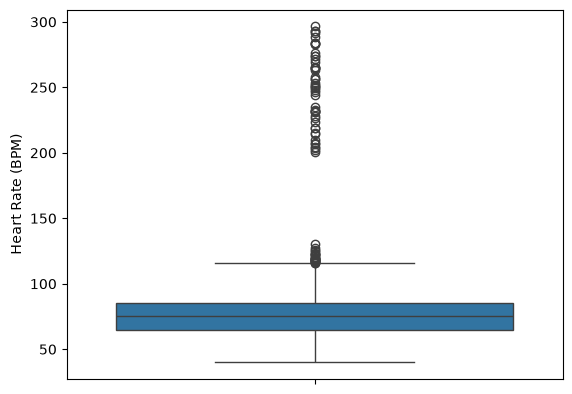

In [16]:
sns.boxplot(data=df,y='Heart Rate (BPM)')
plt.show()

<Axes: >

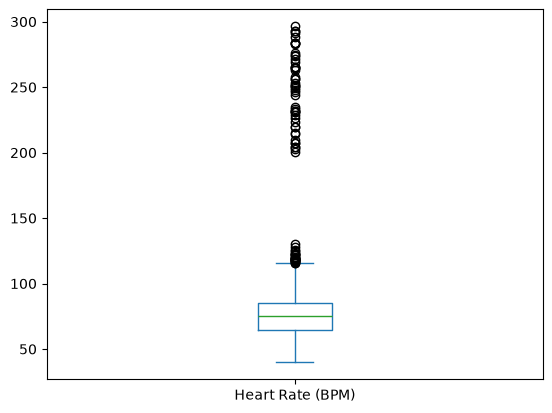

In [17]:
df['Heart Rate (BPM)'].plot(kind='box')

In [18]:
df.dropna(subset=['Heart Rate (BPM)'],inplace=True)

In [19]:
df.isnull().sum()

Heart Rate (BPM)            0
Blood Oxygen Level (%)    289
Step Count                 94
Sleep Duration (hours)    145
Activity Level            191
Stress Level              193
dtype: int64

<Axes: xlabel='Blood Oxygen Level (%)'>

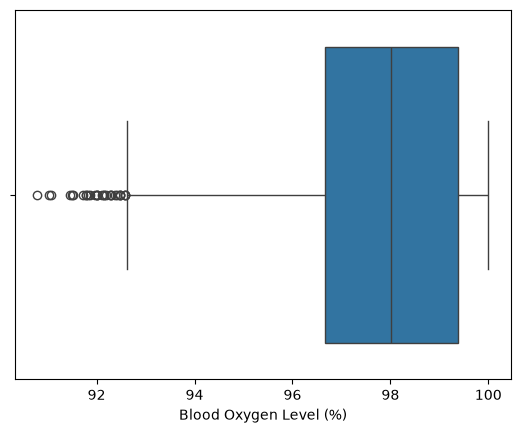

In [20]:
sns.boxplot(data=df,x='Blood Oxygen Level (%)')

In [21]:
df['Blood Oxygen Level (%)'].describe()

count    9311.000000
mean       97.844300
std         1.731948
min        90.791208
25%        96.667486
50%        98.013264
75%        99.377124
max       100.000000
Name: Blood Oxygen Level (%), dtype: float64

In [26]:
df['Blood Oxygen Level (%)']=df['Blood Oxygen Level (%)'].fillna(97.8443,inplace=True)

/var/folders/c1/6c8s3wn93nd1yg_s50mdh4nc0000gn/T/ipykernel_8551/1329554852.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Blood Oxygen Level (%)']=df['Blood Oxygen Level (%)'].fillna(97.8443,inplace=True)


In [27]:
df['Step Count'].describe()

count     9506.000000
mean      6963.944541
std       6858.230746
min          0.910138
25%       2014.650691
50%       4953.616153
75%       9716.159665
max      62486.690753
Name: Step Count, dtype: float64

In [29]:
mean=df['Step Count'].mean()
df['Step Count']=df['Step Count'].fillna(mean,inplace=True)

/var/folders/c1/6c8s3wn93nd1yg_s50mdh4nc0000gn/T/ipykernel_8551/2688134031.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Step Count']=df['Step Count'].fillna(mean,inplace=True)


In [30]:
df.isnull().sum()

Heart Rate (BPM)            0
Blood Oxygen Level (%)      0
Step Count                  0
Sleep Duration (hours)    145
Activity Level            191
Stress Level              193
dtype: int64

In [31]:
df['Sleep Duration (hours)'].describe()

count      9455
unique     9219
top       ERROR
freq        237
Name: Sleep Duration (hours), dtype: object

In [37]:
px=df[df['Sleep Duration (hours)'] != 'ERROR']

In [41]:
px['Sleep Duration (hours)']= px['Sleep Duration (hours)'].astype('float32')

In [42]:
px['Sleep Duration (hours)'].mean()

np.float32(6.5047407)

In [47]:
df['Sleep Duration (hours)']= df['Sleep Duration (hours)'].replace('ERROR',6.5047407,inplace=True)

/var/folders/c1/6c8s3wn93nd1yg_s50mdh4nc0000gn/T/ipykernel_8551/3359317362.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Sleep Duration (hours)']= df['Sleep Duration (hours)'].replace('ERROR',6.5047407,inplace=True)


In [52]:
df['Sleep Duration (hours)']=df['Sleep Duration (hours)'].astype('float32')

In [55]:
df['Sleep Duration (hours)'].describe()

count    9455.000000
mean        6.504741
std         1.490433
min        -0.194453
25%         5.524491
50%         6.504741
75%         7.496352
max        12.140233
Name: Sleep Duration (hours), dtype: float64

In [56]:
df['Sleep Duration (hours)']=df['Sleep Duration (hours)'].fillna(6.504741,inplace=True)

/var/folders/c1/6c8s3wn93nd1yg_s50mdh4nc0000gn/T/ipykernel_8551/513381380.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Sleep Duration (hours)']=df['Sleep Duration (hours)'].fillna(6.504741,inplace=True)


In [57]:
df.isnull().sum()

Heart Rate (BPM)            0
Blood Oxygen Level (%)      0
Step Count                  0
Sleep Duration (hours)      0
Activity Level            191
Stress Level              193
dtype: int64

In [58]:
df['Sleep Duration (hours)'].dtype

dtype('float32')

In [59]:
df['Activity Level'].value_counts()

Activity Level
Seddentary       1616
Sedentary        1598
Highly Active    1580
Actve            1566
Active           1566
Highly_Active    1483
Name: count, dtype: int64

In [60]:
df.dropna(subset=['Activity Level'],inplace=True)

In [61]:
df.isnull().sum()

Heart Rate (BPM)            0
Blood Oxygen Level (%)      0
Step Count                  0
Sleep Duration (hours)      0
Activity Level              0
Stress Level              190
dtype: int64

In [62]:
df['Stress Level'].value_counts()

Stress Level
2            955
6            946
7            945
3            938
1            935
9            924
4            906
10           886
5            879
8            860
Very High     45
Name: count, dtype: int64

In [63]:
df['Stress Level'].isnull().sum()

np.int64(190)

In [67]:
df['Stress Level']=df['Stress Level'].fillna('5',inplace=True)

/var/folders/c1/6c8s3wn93nd1yg_s50mdh4nc0000gn/T/ipykernel_8551/3575829337.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Stress Level']=df['Stress Level'].fillna('5',inplace=True)


In [68]:
df.isnull().sum()

Heart Rate (BPM)          0
Blood Oxygen Level (%)    0
Step Count                0
Sleep Duration (hours)    0
Activity Level            0
Stress Level              0
dtype: int64